# Brain Cancer Detection using MRI Images

### Objective

Develop a Convolutional Neural Network (CNN) to classify MRI brain images into Tumor and No Tumor categories.

### Deep Learning Framework

- TensorFlow
- Keras

### Goal

Detect brain tumors from MRI images using deep learning.

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

2026-07-26 23:03:46.658161: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.16.2


In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    "../dataset/brain_tumor_dataset",
    target_size=(128,128),
    batch_size=32,
    class_mode="binary",
    subset="training"
)

validation_generator = train_datagen.flow_from_directory(
    "../dataset/brain_tumor_dataset",
    target_size=(128,128),
    batch_size=32,
    class_mode="binary",
    subset="validation"
)

Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


In [4]:
print("Classes:", train_generator.class_indices)
print("Training Images:", train_generator.samples)
print("Validation Images:", validation_generator.samples)

Classes: {'no': 0, 'yes': 1}
Training Images: 203
Validation Images: 50


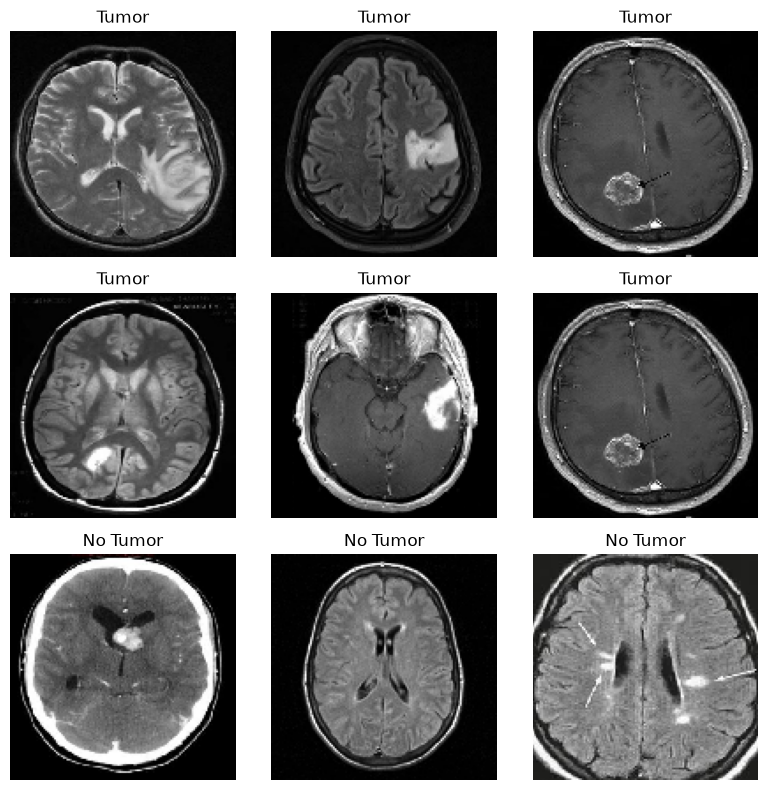

In [5]:
images, labels = next(train_generator)

plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title("Tumor" if labels[i] == 1 else "No Tumor")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Build the Convolutional Neural Network (CNN)

A CNN is designed to automatically learn important features from images.

Architecture:
- Conv2D
- MaxPooling2D
- Conv2D
- MaxPooling2D
- Flatten
- Dense
- Dropout
- Output Layer

In [6]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

/Users/khushi/AI-ML-Projects/dl_env/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Model Summary

Display the architecture and number of trainable parameters.

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,449 (28.20 MB)

 Trainable params: 7,392,449 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

# Compile the Model

Configure the CNN for training.

- Optimizer: Adam
- Loss Function: Binary Crossentropy
- Metric: Accuracy

In [8]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train the CNN Model

Train the model using the MRI image dataset.

In [9]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.6552 - loss: 0.7776 - val_accuracy: 0.7400 - val_loss: 0.5385
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 997ms/step - accuracy: 0.8079 - loss: 0.4941 - val_accuracy: 0.7400 - val_loss: 0.5394
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 687ms/step - accuracy: 0.8227 - loss: 0.4030 - val_accuracy: 0.7400 - val_loss: 0.5647
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 803ms/step - accuracy: 0.8621 - loss: 0.3154 - val_accuracy: 0.7400 - val_loss: 0.4799
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 684ms/step - accuracy: 0.8818 - loss: 0.2696 - val_accuracy: 0.8000 - val_loss: 0.6262
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 732ms/step - accuracy: 0.9113 - loss: 0.2406 - val_accuracy: 0.8400 - val_loss: 0.4258
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 695ms/step - accuracy: 0.9507 - loss: 0.1341 - val_accuracy: 0.8400 - val_loss: 0.5441
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 729ms/step - accuracy: 0.9606 - loss: 0.1075 - val_accuracy: 0.7600 - val_loss: 

# Evaluate the Model

Measure the performance of the trained model.

In [10]:
loss, accuracy = model.evaluate(validation_generator)

print("Validation Loss :", loss)
print("Validation Accuracy :", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 200ms/step - accuracy: 0.8400 - loss: 0.6518
Validation Loss : 0.6517654657363892
Validation Accuracy : 0.8399999737739563


# Training vs Validation Accuracy

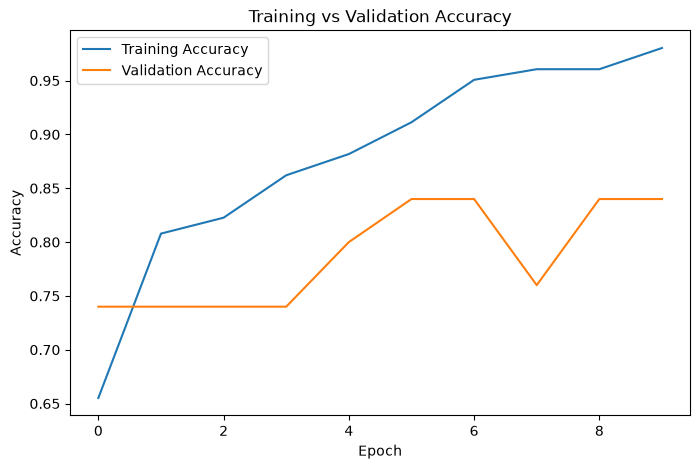

In [11]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

# Training vs Validation Loss

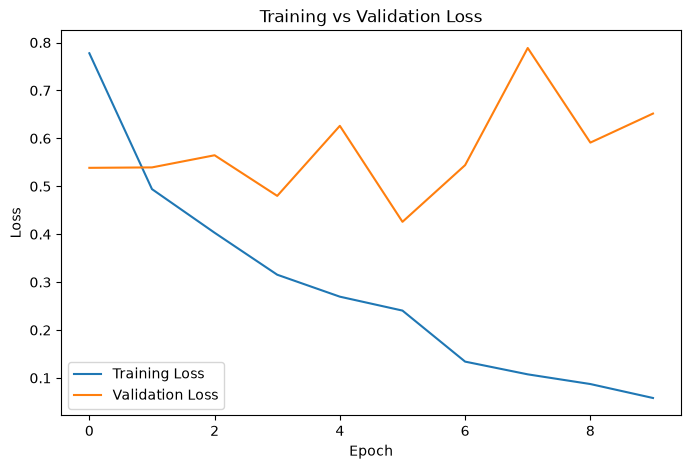

In [12]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

# Save the Trained Model

In [13]:
model.save("../models/brain_cancer_detection.keras")

print("Model saved successfully.")

Model saved successfully.


# Predict MRI Images

Use the trained model to predict whether an MRI image contains a brain tumor.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


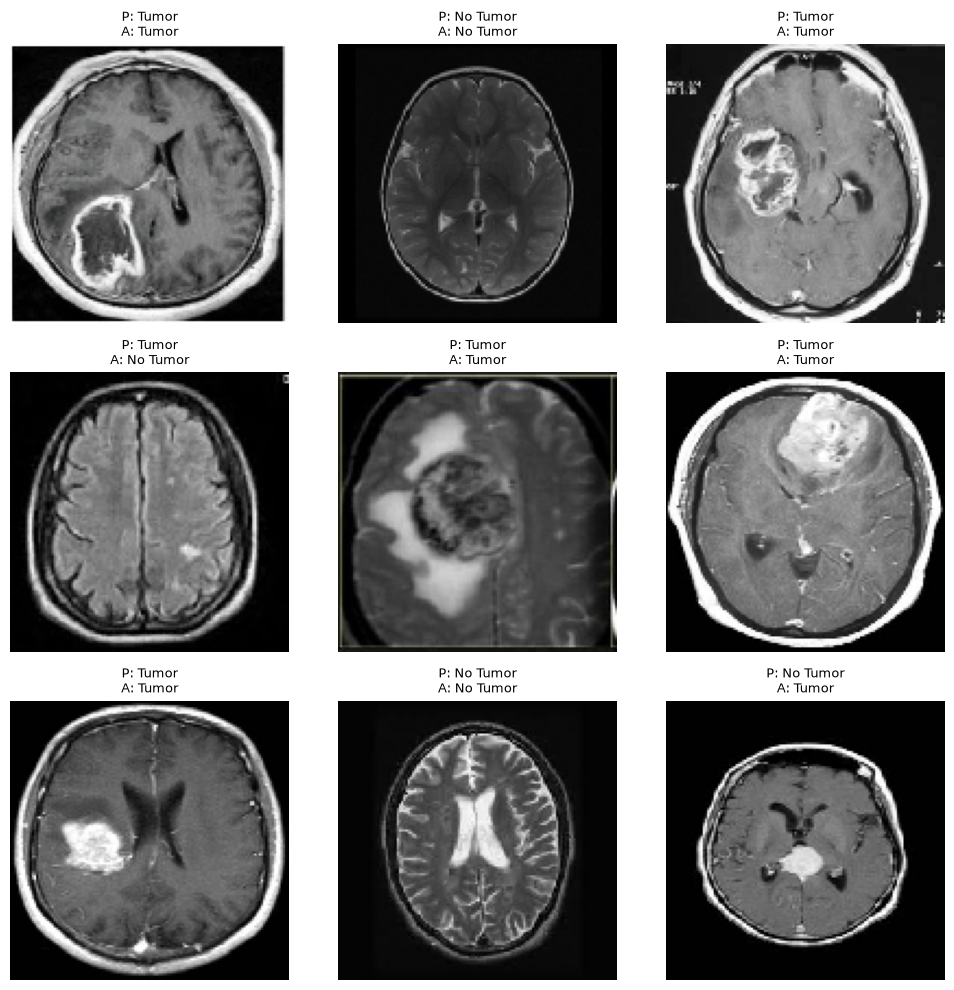

In [14]:
images, labels = next(validation_generator)

predictions = model.predict(images)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])

    predicted = "Tumor" if predictions[i] > 0.5 else "No Tumor"
    actual = "Tumor" if labels[i] == 1 else "No Tumor"

    plt.title(f"P: {predicted}\nA: {actual}", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

# Conclusion

A Convolutional Neural Network (CNN) was developed to classify brain MRI images into Tumor and No Tumor categories.

The model was trained, evaluated, and successfully used to predict unseen MRI images. The trained model was saved for future inference.

This project demonstrates a complete deep learning workflow for medical image classification.